<a href="https://colab.research.google.com/github/Nainsarkee100/PY/blob/main/Machine%20Learning%20with%20Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
           'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

data = pd.read_csv(url, names=columns)


In [4]:
print(data.info())
print(data.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB
None
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.15841

In [5]:
# Check missing values:
print(data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


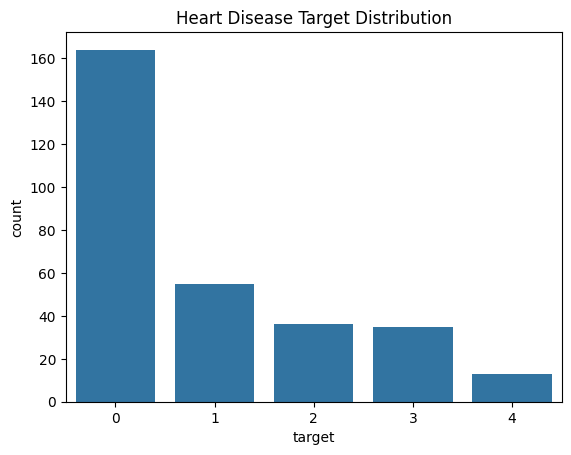

In [6]:
#Data Visualization and Target Distribution
sns.countplot(x='target', data=data)
plt.title("Heart Disease Target Distribution")
plt.show()

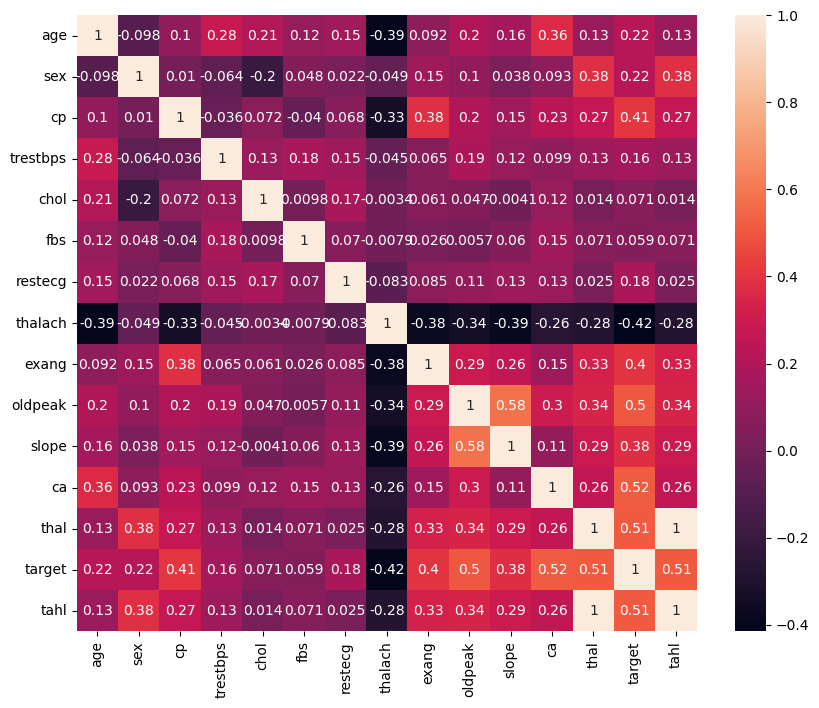

In [9]:
data['ca'] = pd.to_numeric(data['ca'], errors='coerce')
data['thal'] = pd.to_numeric(data['thal'], errors='coerce')

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True)
plt.show()

In [12]:
#Convert target to binary
data['target'] = data['target'].apply(lambda x: 1 if x > 0 else 0)

In [13]:
#Features and target
x = data.drop('target', axis=1)
y = data['target']

In [ ]:
#Separate Feature and Target
x = data.drop('target', axis=1)
y = data['target']

In [17]:
#Split Training and Testing Data
x_train, X_test, y_train, y_test = train_test_split(
x, y, test_size=0.2, random_state=42)

In [16]:
#Train Decision Tree Model
model = DecisionTreeClassifier(criterion='entropy')

model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [21]:
#Make Predictions
y_pred = model.predict(X_test)

In [22]:
#Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8032786885245902


In [23]:
#Confusion Matrix
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8032786885245902


In [24]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.83      0.80        29
           1       0.83      0.78      0.81        32

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



In [27]:
#Predict New Patient
patient = [[63,1,3,145,233,1,0,150,0,2,3,0,0,1]]

prediction = model.predict(patient)
if prediction[0] == 1:
  print("Patient has Heart Disease")
else:
  print("Patient does not have Heart Disease")

Patient does not have Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
